In [76]:
# Parámetros globales para reproducibilidad y configuración
SEED = 42
N_JORNADAS = 2600
N_DIAS = 365

import random, numpy as np
random.seed(SEED)
np.random.seed(SEED)

import os
os.makedirs('figures', exist_ok=True)

# Iniciación de paquetes

In [ ]:
import random
import pandas as pd
import matplotlib.pyplot as plt
import math
import numpy as np
import os

random.seed(SEED)
np.random.seed(SEED)

# Lectura de Dataframes

In [78]:
salarios = pd.read_csv('data/Salary_Data_Based_country_and_race.csv')
llamadas = pd.read_csv('data/simulated_call_centre.csv')

# Análisis de sueldos para personas Senior y Junior

In [ ]:
display(salarios.head(10))

,Unnamed: 0,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Country,Race
0,0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0,UK,White
1,1,28.0,Female,Master's,Data Analyst,3.0,65000.0,USA,Hispanic
2,2,45.0,Male,PhD,Senior Manager,15.0,150000.0,Canada,White
3,3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0,USA,Hispanic
4,4,52.0,Male,Master's,Director,20.0,200000.0,USA,Asian
5,5,29.0,Male,Bachelor's,Marketing Analyst,2.0,55000.0,USA,Hispanic
6,6,42.0,Female,Master's,Product Manager,12.0,120000.0,USA,Asian
7,7,31.0,Male,Bachelor's,Sales Manager,4.0,80000.0,China,Korean
8,8,26.0,Female,Bachelor's,Marketing Coordinator,1.0,45000.0,China,Chinese
9,9,38.0,Male,PhD,Senior Scientist,10.0,110000.0,Australia,Australian


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,6704.0,NaN,NaN,NaN,3351.5,1935.422435,0.0,1675.75,3351.5,5027.25,6703.0
Age,6702.0,NaN,NaN,NaN,33.620859,7.614633,21.0,28.0,32.0,38.0,62.0
Gender,6702,3,Male,3674,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education Level,6701,7,Bachelor's Degree,2267,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job Title,6702,193,Software Engineer,518,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Years of Experience,6701.0,NaN,NaN,NaN,8.094687,6.059003,0.0,3.0,7.0,12.0,34.0
Salary,6699.0,NaN,NaN,NaN,115326.964771,52786.183911,350.0,70000.0,115000.0,160000.0,250000.0
Country,6704,5,USA,1360,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Race,6704,10,White,1968,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [80]:
# 1. Filtramos el DataFrame para obtener solo a los Sales Associate
asesores_de_ventas = salarios[salarios['Job Title'] == 'Sales Associate']

# 2. Mostramos los salarios individuales (puedes ver más columnas si lo deseas)
print("Listado de salarios para Sales Associates:")
print(asesores_de_ventas[['Job Title', 'Salary']])


# 3. Calculamos la media salarial
media_salarial = asesores_de_ventas['Salary'].mean()

print(f"\nLa media salarial de los Sales Associates es: ${media_salarial:,.2f}")

Listado de salarios para Sales Associates:
            Job Title   Salary
3     Sales Associate  60000.0
91    Sales Associate  40000.0
4880  Sales Associate  30000.0
4893  Sales Associate  30000.0
4906  Sales Associate  30000.0
...               ...      ...
6644  Sales Associate  50000.0
6661  Sales Associate  35000.0
6672  Sales Associate  50000.0
6689  Sales Associate  35000.0
6700  Sales Associate  50000.0

[70 rows x 2 columns]

La media salarial de los Sales Associates es: $35,857.14


In [81]:
# Junior: 0 a 2 años
asesores_jr = asesores_de_ventas[asesores_de_ventas['Years of Experience'].between(0, 2)]

# Semi-Senior: más de 2 hasta 5 años
asesores_ssr = asesores_de_ventas[asesores_de_ventas['Years of Experience'].between(2.1, 5)]

# Senior: más de 5 años
asesores_sr = asesores_de_ventas[asesores_de_ventas['Years of Experience'] > 5]

Ahora veamos los sueldos de gente con poca experiencia contra los que tienen mas

In [82]:
for df,name in [(asesores_jr,'junior'),(asesores_ssr,'semi-senior'),(asesores_sr,'senior')]:
    print(f"--- {name} ---")
    display(df.head(10))
    display(df.describe().T)

--- junior ---


,Unnamed: 0,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Country,Race
4880,4880,24.0,Female,High School,Sales Associate,1.0,30000.0,Australia,Australian
4893,4893,24.0,Female,High School,Sales Associate,1.0,30000.0,UK,Welsh
4906,4906,24.0,Female,High School,Sales Associate,1.0,30000.0,Canada,White
4919,4919,24.0,Female,High School,Sales Associate,1.0,30000.0,Canada,Black
4932,4932,24.0,Female,High School,Sales Associate,1.0,30000.0,UK,Asian
4945,4945,24.0,Female,High School,Sales Associate,1.0,30000.0,Canada,Asian
4958,4958,24.0,Female,High School,Sales Associate,1.0,30000.0,Canada,Asian
4971,4971,24.0,Female,High School,Sales Associate,1.0,30000.0,USA,White
4984,4984,24.0,Female,High School,Sales Associate,1.0,30000.0,UK,Asian
4997,4997,24.0,Female,High School,Sales Associate,1.0,30000.0,China,Korean


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,50.0,5524.92,628.174642,4880.0,5030.25,5251.0,6280.0,6689.0
Age,50.0,24.64,1.381511,22.0,24.00,24.0,25.0,31.0
Years of Experience,50.0,0.72,0.536048,0.0,0.00,1.0,1.0,2.0
Salary,50.0,30200.00,4624.689730,25000.0,25000.00,30000.0,35000.0,45000.0


--- semi-senior ---


,Unnamed: 0,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Country,Race
91,91,29.0,Female,Bachelor's,Sales Associate,3.0,40000.0,China,White
6331,6331,31.0,Male,Bachelor's Degree,Sales Associate,3.0,50000.0,China,Korean
6373,6373,31.0,Male,High School,Sales Associate,3.0,50000.0,Australia,Asian
6387,6387,31.0,Male,High School,Sales Associate,3.0,50000.0,China,Chinese
6401,6401,31.0,Male,High School,Sales Associate,3.0,50000.0,Canada,White
6415,6415,31.0,Male,High School,Sales Associate,3.0,50000.0,UK,Asian
6429,6429,31.0,Male,High School,Sales Associate,3.0,50000.0,Australia,Asian
6443,6443,31.0,Male,High School,Sales Associate,3.0,50000.0,Australia,Australian
6492,6492,31.0,Male,High School,Sales Associate,3.0,50000.0,Australia,White
6506,6506,31.0,Male,High School,Sales Associate,3.0,50000.0,Australia,White


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,19.0,6170.526316,1475.972499,91.0,6408.0,6506.0,6569.0,6700.0
Age,19.0,31.105263,0.657836,29.0,31.0,31.0,31.0,32.0
Years of Experience,19.0,3.000000,0.000000,3.0,3.0,3.0,3.0,3.0
Salary,19.0,49473.684211,2294.157339,40000.0,50000.0,50000.0,50000.0,50000.0


--- senior ---


,Unnamed: 0,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Country,Race
3,3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0,USA,Hispanic


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,1.0,3.0,NaN,3.0,3.0,3.0,3.0,3.0
Age,1.0,36.0,NaN,36.0,36.0,36.0,36.0,36.0
Years of Experience,1.0,7.0,NaN,7.0,7.0,7.0,7.0,7.0
Salary,1.0,60000.0,NaN,60000.0,60000.0,60000.0,60000.0,60000.0


In [83]:
salario_medio_jr = asesores_jr['Salary'].mean()
salario_medio_ssr = asesores_ssr['Salary'].mean()
salario_medio_sr = asesores_sr['Salary'].mean()
print(f'El salario medio de un asesor junior es de {(salario_medio_jr/12)*0.8436:,.2f} euros => {((salario_medio_jr/12)/200)*0.8436:,.2f}')
print(f'El salario medio de un asesor semi-senior es de {(salario_medio_ssr/12)*0.8436:,.2f} euros')
print(f'El salario medio de un asesor senior es de {(salario_medio_sr/12)*0.8436:,.2f} euros')

El salario medio de un asesor junior es de 2,123.06 euros => 10.62
El salario medio de un asesor semi-senior es de 3,478.00 euros
El salario medio de un asesor senior es de 4,218.00 euros


Estos son los datos que vamos a tomar para hacer nuestro estudio de optimización económica

# Análisis de tasas de llegada y salida aproximadamente

In [84]:
# apenas un vistazo inicial

display(llamadas.head(10))
display(llamadas.describe(include='all').T)

,call_id,date,daily_caller,call_started,call_answered,call_ended,wait_length,service_length,meets_standard
0,1,2021-01-01,1,8:00:00 AM,8:00:00 AM,8:14:22 AM,0,863,True
1,2,2021-01-01,2,8:02:42 AM,8:02:42 AM,8:07:31 AM,0,289,True
2,3,2021-01-01,3,8:08:24 AM,8:08:24 AM,8:10:13 AM,0,108,True
3,4,2021-01-01,4,8:09:37 AM,8:09:37 AM,8:13:45 AM,0,247,True
4,5,2021-01-01,5,8:11:10 AM,8:11:10 AM,8:15:28 AM,0,258,True
5,6,2021-01-01,6,8:22:33 AM,8:22:33 AM,8:28:13 AM,0,340,True
6,7,2021-01-01,7,8:23:18 AM,8:23:18 AM,8:34:14 AM,0,656,True
7,8,2021-01-01,8,8:23:57 AM,8:23:57 AM,8:29:37 AM,0,341,True
8,9,2021-01-01,9,8:25:08 AM,8:25:08 AM,8:25:32 AM,0,23,True
9,10,2021-01-01,10,8:27:58 AM,8:27:58 AM,8:37:40 AM,0,582,True


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
call_id,51708.0,NaN,NaN,NaN,25854.5,14926.958196,1.0,12927.75,25854.5,38781.25,51708.0
date,51708,261,2021-12-10,297,NaN,NaN,NaN,NaN,NaN,NaN,NaN
daily_caller,51708.0,NaN,NaN,NaN,104.193239,64.95288,1.0,50.0,100.0,150.0,297.0
call_started,51708,27403,8:00:00 AM,261,NaN,NaN,NaN,NaN,NaN,NaN,NaN
call_answered,51708,27366,8:00:00 AM,261,NaN,NaN,NaN,NaN,NaN,NaN,NaN
call_ended,51708,27486,11:54:17 AM,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wait_length,51708.0,NaN,NaN,NaN,17.034927,64.060769,0.0,0.0,0.0,0.0,983.0
service_length,51708.0,NaN,NaN,NaN,299.102595,299.865751,0.0,86.0,208.0,414.0,3110.0
meets_standard,51708,2,True,47481,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Vamos a ver cuanta gente llama cada mes, de esa forma encontramos un lambda para cada mes y luego hacemos la media de todos esos lambdas para ver el lambda que tomamos para optimizar nuestro negocio

In [85]:
import pandas as pd
import numpy as np

# 1. Asegurar formato de fecha y tiempo
llamadas['date'] = pd.to_datetime(llamadas['date'])
llamadas['call_started'] = pd.to_datetime(
    llamadas['date'].dt.strftime('%Y-%m-%d') + ' ' + llamadas['call_started'].astype(str)
)

# 2. Cálculos generales
total_llamadas = len(llamadas)
dias_operativos = llamadas['date'].dt.date.nunique()
horas_totales = dias_operativos * 10  # Asumiendo jornada de 10 horas

lambda_medio = total_llamadas / horas_totales

# 3. Definir jornada (ejemplo: de 8:00 a 17:59)
horas_jornada = range(8, 18)
pesos_lambda = []

for h in horas_jornada:
    df_hora = llamadas[llamadas['call_started'].dt.hour == h]
    n_llamadas = len(df_hora)
    lambda_h = n_llamadas / dias_operativos 
    peso_lambda = lambda_h / lambda_medio
    pesos_lambda.append(round(peso_lambda, 4))

# 4. Mostrar resultados resumidos
print(f"Total de llamadas en el año: {total_llamadas}")
print(f"Días de operación detectados: {dias_operativos}")
print(f"λ medio anual: {lambda_medio:.2f} clientes/hora")
arr = np.array(pesos_lambda)
print("Pesos lambda (n={}, media={:.3f}, p50={:.3f}, p90={:.3f}, p95={:.3f})".format(
    len(arr), arr.mean(), np.percentile(arr,50), np.percentile(arr,90), np.percentile(arr,95)
))

Total de llamadas en el año: 51708
Días de operación detectados: 261
λ medio anual: 19.81 clientes/hora
Pesos lambda (n=10, media=1.000, p50=1.012, p90=1.028, p95=1.040)


El dataset que hemos elegido es evidente que está muy limpio y uniformado ya que los pesos siguen una distirbucion uniforme => vamos a establecer nuestros propios lambdas ya que en la vida real los clientes no funcionan así, de esta forma definimos pesos = [0.8, 1.2, 1.4, 1.1, 0.7, 0.6, 1.2, 1.1, 1.0, 0.9], pero eso lo usaremos dentro de un rato, primero vamos a ver en regimen estacionario como funciona el sistema y cuantos asesores son los optimos para nuestro sistema, suponiendo que cada asesor atiende con un mu = 3 de media aunque ya veremos despues en la configuracion de los equipos que eso no va a ocurrir asi.

Como en principio estamos respetando el estatuto de trrabajadores legal en España, debemos respetar la jornada de 40h semanales, gracias al hecho de que la distribución de los lambdas en este caso siguen una distribución uniforme, podemos tomar el lambda de 20 y seguir con nuestros pesos diseñados para seguir el comportamiento natural humano y poder ver como los distintos equipos tienen o no capacidad para limpiar las colas que se forman

# Métricas iniciales

In [86]:
import math

def metricas_estaticas(lambda_tasa, mu, s):
   
    rho = lambda_tasa / (s * mu)

    termino_sumatorio = sum([(lambda_tasa/mu)**n / math.factorial(n) for n in range(s)])
    termino_cola = ((lambda_tasa/mu)**s / (math.factorial(s) * (1 - rho)))
    pi0 = 1 / (termino_sumatorio + termino_cola)
    
  
    Lq = (pi0 * ((lambda_tasa/mu)**s) * rho) / (math.factorial(s) * (1 - rho)**2)
    Wq = Lq / lambda_tasa
    W = Wq + (1/mu)
    L = lambda_tasa * W
    
    # Devolvemos un diccionario con todo
    return {
        "rho": round(rho, 3),
        "Lq": round(Lq, 3),
        "Wq_min": round(Wq*60, 3),
        "L": round(L, 3),
        "lambda": round(lambda_tasa, 3),
        "mu": mu,
        "servidores": s
    }

Aún no nos interesa la optimización del dinero, de momento vamos a fijarnos en los factores de utilización y ocupacion de las colas

In [87]:
metricas_teoricas7 = metricas_estaticas(20, 3, 7)
metricas_teoricas8 = metricas_estaticas(20, 3, 8)
metricas_teoricas9 = metricas_estaticas(20, 3, 9)
print('Aqui no tenemos en cuenta el dinero que cuesta un cliente en cola ni los sueldos cada asesor')
print('estadisticas con 7 servidores:', metricas_teoricas7)
print('estadisticas con 8 servidores:', metricas_teoricas8)
print('estadisticas con 9 servidores:', metricas_teoricas9)


Aqui no tenemos en cuenta el dinero que cuesta un cliente en cola ni los sueldos cada asesor
estadisticas con 7 servidores: {'rho': 0.952, 'Lq': 17.223, 'Wq_min': 51.668, 'L': 23.889, 'lambda': 20, 'mu': 3, 'servidores': 7}
estadisticas con 8 servidores: {'rho': 0.833, 'Lq': 2.663, 'Wq_min': 7.99, 'L': 9.33, 'lambda': 20, 'mu': 3, 'servidores': 8}
estadisticas con 9 servidores: {'rho': 0.741, 'Lq': 0.895, 'Wq_min': 2.685, 'L': 7.562, 'lambda': 20, 'mu': 3, 'servidores': 9}


Se puede ver como en regimen estático el sistema con 7 servidores se colapsa => si simulamos un sistema con 7 servidores, a la mínima que haya un pequeño pico de demanda la cola va a crecer sin fin y los asesores van a estar abarrotados

En cambio si disponemos de 8 o 9 asesores los factores de utilizacion del sistema están mucho mas equilibrados y pueden soportar puntos criticos de demanda con unos tiempos de espera de 8 minutos (8 asesores) y 2.7 minutos (9 asesores).
Es evidente que el sistema con 9 servidores va a funcionar muy fluido pero puede ser qu se pague demasiado dinero en asesores => eso es lo que vamos a analizar y tambien que configuracion de equipo puede ser la optima ya que no es lo mismo 9 asesores semi-senior que 5 senior y 4 junior etc.
De esta forma pasamos a la simulación

# Función de simulación de llegadas y salidas

In [88]:
import numpy as np
import pandas as pd

def generacion_llegadas(lambda_base, pesos_horarios):
    tiempos = []
    t = 0.0
    for hora, peso in enumerate(pesos_horarios):
        tasa = lambda_base * peso
        # mueve el reloj al inicio exacto de la hora
        t = float(hora)

        if tasa <= 0:
            continue

        while True:
            t += np.random.exponential(1 / tasa)
            if t >= hora + 1:
                break
            tiempos.append(t)

    return tiempos

def simulacion_atencion(asesores, llegadas):
    
    disponibilidad = [0.0] * len(asesores)
    esperas = []
    for llegada in llegadas:
        libre = min(disponibilidad)
        idx = disponibilidad.index(libre)
        inicio = max(llegada, libre)
        esperas.append(inicio - llegada)
        # El mu depende del asesor específico asignado
        t_serv = np.random.exponential(1 / asesores[idx]['mu'])
        disponibilidad[idx] = inicio + t_serv
    return esperas

def simulacion_total(n_iteraciones, lambda_base, pesos, lista_asesores, coste_espera_h):
    
    record_wq = []
    record_costes_espera = []
    
    # Coste fijo de los salarios (Suma de costes/h * 8 horas)
    coste_fijo_asesores = sum([a['coste'] for a in lista_asesores]) * len(pesos)

    lambda_media = lambda_base * np.mean(pesos)
    capacidad_total = sum(a['mu'] for a in lista_asesores)
    rho = lambda_media / capacidad_total

    
    for _ in range(n_iteraciones):
        llegadas = generacion_llegadas(lambda_base, pesos)
        esperas = simulacion_atencion(lista_asesores, llegadas)
        
        if esperas:
            wq_dia = np.mean(esperas)
            coste_espera_dia = sum(esperas) * coste_espera_h
            record_wq.append(wq_dia * 60) # Pasamos a minutos
            record_costes_espera.append(coste_espera_dia)

    # Consolidación Estadística
    return {
        "Wq Medio (min)": round(np.mean(record_wq), 2),
        "Incertidumbre (Std Dev min)": round(np.std(record_wq), 2),
        "Coste Salarios (€/día)": coste_fijo_asesores,
        "Coste Espera Medio (€/día)": round(np.mean(record_costes_espera), 2),
        "Coste Total Medio (€/día)": round(coste_fijo_asesores + np.mean(record_costes_espera), 2),
        "Factor de utilización medio": round(rho, 2)
    }

def registrar_experimento(nombre_escenario, n_iteraciones, lambda_base, pesos, lista_asesores, coste_wait_h):
    """
    Ejecuta la simulación y devuelve un DataFrame con los parámetros y resultados aplanados.
    """
    # 1. Ejecutar tu lógica original
    res = simulacion_total(n_iteraciones, lambda_base, pesos, lista_asesores, coste_wait_h)
    
    # 2. Crear el diccionario de parámetros de entrada
    # Calculamos el mu promedio del equipo para tener una referencia rápida
    mu_promedio = np.mean([a['mu'] for a in lista_asesores])
    
    config = {
        "Escenario": nombre_escenario,
        "Iteraciones": n_iteraciones,
        "Lambda Base": lambda_base,
        "Num Asesores": len(lista_asesores),
        "Mu Promedio": round(mu_promedio, 2),
        "Coste Espera (€/h)": coste_wait_h,
        "Configuración": f"L={lambda_base}, S={len(lista_asesores)}, Mu={round(mu_promedio,1)}"
    }
    
    # 3. Fusionar Configuración + Resultados en un solo registro
    # Usamos el operador unpacking ** para unir ambos diccionarios
    registro_completo = {**config, **res}
    
    return pd.DataFrame([registro_completo])

# Configuración de equipos

# Equipos base

In [89]:
# Definimos los escenarios a probar
config_asesores_7 = [
    {'nombre': '1', 'mu': 3, 'coste': 17},
    {'nombre': '2', 'mu': 3, 'coste': 17},
    {'nombre': '3', 'mu': 3, 'coste': 17},
    {'nombre': '4', 'mu': 3, 'coste': 17},
    {'nombre': '5', 'mu': 3, 'coste': 17},
    {'nombre': '6', 'mu': 3, 'coste': 17},
    {'nombre': '7', 'mu': 3, 'coste': 17}
] # Equipo de 7 miembros con mu constante

config_asesores_6 = [
    {'nombre': '1', 'mu': 3, 'coste': 17},
    {'nombre': '2', 'mu': 3, 'coste': 17},
    {'nombre': '3', 'mu': 3, 'coste': 17},
    {'nombre': '4', 'mu': 3, 'coste': 17},
    {'nombre': '5', 'mu': 3, 'coste': 17},
    {'nombre': '6', 'mu': 3, 'coste': 17}
] # Equipo de 6 miembros con mu constante

config_asesores_5 = [
    {'nombre': '1', 'mu': 3, 'coste': 17},
    {'nombre': '2', 'mu': 3, 'coste': 17},
    {'nombre': '3', 'mu': 3, 'coste': 17},
    {'nombre': '4', 'mu': 3, 'coste': 17},
    {'nombre': '5', 'mu': 3, 'coste': 17}
] # Equipo de 5 miembros con mu constante

config_asesores_8 = [
    {'nombre': '1', 'mu': 3, 'coste': 17},
    {'nombre': '2', 'mu': 3, 'coste': 17},
    {'nombre': '3', 'mu': 3, 'coste': 17},
    {'nombre': '4', 'mu': 3, 'coste': 17},
    {'nombre': '5', 'mu': 3, 'coste': 17},
    {'nombre': '6', 'mu': 3, 'coste': 17},
    {'nombre': '7', 'mu': 3, 'coste': 17},
    {'nombre': '8', 'mu': 3, 'coste': 17}
] # Equipo de 8 miembros con mu constante

config_asesores_9 = [
    {'nombre': '1', 'mu': 3, 'coste': 17},
    {'nombre': '2', 'mu': 3, 'coste': 17},
    {'nombre': '3', 'mu': 3, 'coste': 17},
    {'nombre': '4', 'mu': 3, 'coste': 17},
    {'nombre': '5', 'mu': 3, 'coste': 17},
    {'nombre': '6', 'mu': 3, 'coste': 17},
    {'nombre': '7', 'mu': 3, 'coste': 17},
    {'nombre': '8', 'mu': 3, 'coste': 17},
    {'nombre': '9', 'mu': 3, 'coste': 17}
] # Equipo de 9 miembros con mu constante

# Equipos mixtos

In [90]:
# Definimos los escenarios a probar
config_asesores_7_mixtos_1 = [
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15}
] 

config_asesores_7_mixtos_2 = [
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15}
]

config_asesores_8_mixtos_1 = [
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15}
] 

config_asesores_8_mixtos_2 = [
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15}
] 

config_asesores_6_mixtos_1 = [
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
]

config_asesores_6_mixtos_2 = [
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15}
]

config_asesores_4_senior = [
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
]

config_asesores_5_senior = [
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
]

config_asesores_6_senior = [
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
    {'nombre': 'Senior', 'mu': 4, 'coste': 30},
]

config_asesores_8_junior = [
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15},
    {'nombre': 'Junior', 'mu': 2.5, 'coste': 15}
]

# Variables de resultados

## Resultados en escenarios de barrido de staff en días intermedios

In [101]:
experimentos1 = []
pesos_dia = [0.8, 1.2, 1.4, 1.1, 0.7, 0.6, 1.2, 1.1, 1.0, 0.9]
iteraciones = 500


# Escenario 1
experimentos1.append(registrar_experimento("Base (9 asesores)", iteraciones, 20, pesos_dia, config_asesores_9, 35))

# Escenario 2
experimentos1.append(registrar_experimento("Base (8 asesores)", iteraciones, 20, pesos_dia, config_asesores_8, 35))

# Escenario 3
experimentos1.append(registrar_experimento("Base (7 asesores)", iteraciones, 20, pesos_dia, config_asesores_7, 35))

# Escenario 4
experimentos1.append(registrar_experimento("Base (6 asesores)", iteraciones, 20, pesos_dia, config_asesores_6, 35))

# Escenario 5
experimentos1.append(registrar_experimento("Base (5 asesores)", iteraciones, 20, pesos_dia, config_asesores_5, 35))

# Escenario 6
experimentos1.append(registrar_experimento("Alta demanda (9 asesores)", iteraciones, 25, pesos_dia, config_asesores_9, 35))

# Escenario 7
experimentos1.append(registrar_experimento("Alta demanda (7 asesores)", iteraciones, 25, pesos_dia, config_asesores_7, 35))

# Escenario 8
experimentos1.append(registrar_experimento("Alta demanda (8 asesores)", iteraciones, 25, pesos_dia, config_asesores_8, 35))

# Consolidamos todo en el DataFrame maestro
df_barrido_staff = pd.concat(experimentos1, ignore_index=True)

display(df_barrido_staff.head(10))

,Escenario,Iteraciones,Lambda Base,Num Asesores,Mu Promedio,Coste Espera (€/h),Configuración,Wq Medio (min),Incertidumbre (Std Dev min),Coste Salarios (€/día),Coste Espera Medio (€/día),Coste Total Medio (€/día),Factor de utilización medio
0,Base (9 asesores),500,20,9,3.0,35,"L=20, S=9, Mu=3.0",3.65,3.43,1530,433.49,1963.49,0.74
1,Base (8 asesores),500,20,8,3.0,35,"L=20, S=8, Mu=3.0",9.15,7.75,1360,1095.26,2455.26,0.83
2,Base (7 asesores),500,20,7,3.0,35,"L=20, S=7, Mu=3.0",21.69,16.48,1190,2598.83,3788.83,0.95
3,Base (6 asesores),500,20,6,3.0,35,"L=20, S=6, Mu=3.0",52.96,28.62,1020,6323.40,7343.40,1.11
4,Base (5 asesores),500,20,5,3.0,35,"L=20, S=5, Mu=3.0",111.22,39.01,850,13198.33,14048.33,1.33
5,Alta demanda (9 asesores),500,25,9,3.0,35,"L=25, S=9, Mu=3.0",16.93,12.19,1530,2534.53,4064.53,0.93
6,Alta demanda (7 asesores),500,25,7,3.0,35,"L=25, S=7, Mu=3.0",70.56,30.54,1190,10464.66,11654.66,1.19
7,Alta demanda (8 asesores),500,25,8,3.0,35,"L=25, S=8, Mu=3.0",35.90,20.54,1360,5356.54,6716.54,1.04


Aquí podemos observar que el dilema es si tenemos 7 asesores para todo el año que rinden bien para situaciones equilibradas u 8 que funcionan bien incluso en momentos de alta demanda

## Resultados en escenarios variados con distintos tipos de equipos mixtos

In [ ]:
experimentos2 = []

# Demanda base

# Escenario 1
experimentos2.append(registrar_experimento("Mixto (4 senior / 3 junior) base", 500, 15, pesos_dia, config_asesores_7_mixtos_1, 35))
experimentos2.append(registrar_experimento("Mixto (4 senior / 3 junior) alta demanda", 500, 20, pesos_dia, config_asesores_7_mixtos_1, 35))

# Escenario 1
experimentos2.append(registrar_experimento("Mixto (3 senior / 4 junior) base", 500, 15, pesos_dia, config_asesores_7_mixtos_2, 35))
experimentos2.append(registrar_experimento("Mixto (3 senior / 4 junior) alta demanda", 500, 20, pesos_dia, config_asesores_7_mixtos_2, 35))

# Escenario 1
experimentos2.append(registrar_experimento("Mixto (3 senior / 3 junior) base", 500, 15, pesos_dia, config_asesores_6_mixtos_1, 35))
experimentos2.append(registrar_experimento("Mixto (3 senior / 3 junior) alta demanda", 500, 20, pesos_dia, config_asesores_6_mixtos_1, 35))

# Escenario 1
experimentos2.append(registrar_experimento("Mixto (2 senior / 4 junior) base", 500, 15, pesos_dia, config_asesores_6_mixtos_2, 35))
experimentos2.append(registrar_experimento("Mixto (2 senior / 4 junior) alta demanda", 500, 20, pesos_dia, config_asesores_6_mixtos_2, 35))

# Escenario 5:
experimentos2.append(registrar_experimento("Mixto (4 senior / 4 junior) base", 500, 15, pesos_dia, config_asesores_8_mixtos_1, 35))
experimentos2.append(registrar_experimento("Mixto (4 senior / 4 junior) alta demanda", 500, 20, pesos_dia, config_asesores_8_mixtos_1, 35))

# Escenario 5:
experimentos2.append(registrar_experimento("Mixto (3 senior / 5 junior) base", 500, 15, pesos_dia, config_asesores_8_mixtos_2, 35))
experimentos2.append(registrar_experimento("Mixto (3 senior / 5 junior) alta demanda", 500, 20, pesos_dia, config_asesores_8_mixtos_2, 35))

# Escenario 1
experimentos2.append(registrar_experimento("Senior (6 senior) base", 500, 15, pesos_dia, config_asesores_6_senior, 35))
experimentos2.append(registrar_experimento("Senior (6 senior) alta demanda", 500, 20, pesos_dia, config_asesores_6_senior, 35))

# Escenario 1
experimentos2.append(registrar_experimento("Senior (5 senior) base", 500, 15, pesos_dia, config_asesores_5_senior, 35))
experimentos2.append(registrar_experimento("Senior (5 senior) alta demanda", 500, 20, pesos_dia, config_asesores_5_senior, 35))

# Escenario 1
experimentos2.append(registrar_experimento("Senior (4 senior) base", 500, 15, pesos_dia, config_asesores_4_senior, 35))
experimentos2.append(registrar_experimento("Senior (4 senior) alta demanda", 500, 20, pesos_dia, config_asesores_4_senior, 35))

# Escenario 1
experimentos2.append(registrar_experimento("Junior (8 junior) base", 500, 15, pesos_dia, config_asesores_8_junior, 35))
experimentos2.append(registrar_experimento("Junior (8 junior) alta demanda", 500, 20, pesos_dia, config_asesores_8_junior, 35))

# Consolidamos todo en el DataFrame maestro
df_Equipos_mixtos1 = pd.concat(experimentos2, ignore_index=True)

# mostramos un subconjunto y estadísticas
display(df_Equipos_mixtos1.head(10))

,Escenario,Iteraciones,Lambda Base,Num Asesores,Mu Promedio,Coste Espera (€/h),Configuración,Wq Medio (min),Incertidumbre (Std Dev min),Coste Salarios (€/día),Coste Espera Medio (€/día),Coste Total Medio (€/día),Factor de utilización medio
0,Mixto (4 senior / 3 junior) base,500,15,7,3.36,35,"L=15, S=7, Mu=3.4",2.39,2.71,1650,217.78,1867.78,0.64
1,Mixto (4 senior / 3 junior) alta demanda,500,20,7,3.36,35,"L=20, S=7, Mu=3.4",10.98,8.45,1650,1310.41,2960.41,0.85
2,Mixto (3 senior / 4 junior) base,500,15,7,3.14,35,"L=15, S=7, Mu=3.1",3.38,3.11,1500,304.66,1804.66,0.68
3,Mixto (3 senior / 4 junior) alta demanda,500,20,7,3.14,35,"L=20, S=7, Mu=3.1",18.19,13.45,1500,2197.44,3697.44,0.91
4,Mixto (3 senior / 3 junior) base,500,15,6,3.25,35,"L=15, S=6, Mu=3.2",8.01,7.34,1350,729.57,2079.57,0.77
5,Mixto (3 senior / 3 junior) alta demanda,500,20,6,3.25,35,"L=20, S=6, Mu=3.2",33.55,20.48,1350,3998.25,5348.25,1.03
6,Mixto (2 senior / 4 junior) base,500,15,6,3.00,35,"L=15, S=6, Mu=3.0",12.92,10.94,1200,1167.38,2367.38,0.83
7,Mixto (2 senior / 4 junior) alta demanda,500,20,6,3.00,35,"L=20, S=6, Mu=3.0",51.93,28.97,1200,6196.68,7396.68,1.11
8,Mixto (4 senior / 4 junior) base,500,15,8,3.25,35,"L=15, S=8, Mu=3.2",1.13,1.44,1800,101.98,1901.98,0.58
9,Mixto (4 senior / 4 junior) alta demanda,500,20,8,3.25,35,"L=20, S=8, Mu=3.2",5.93,5.08,1800,717.02,2517.02,0.77


,count,mean,std,min,25%,50%,75%,max
Iteraciones,20.0,500.0000,0.000000,500.00,500.0000,500.000,500.0000,500.00
Lambda Base,20.0,17.5000,2.564946,15.00,15.0000,17.500,20.0000,20.00
Num Asesores,20.0,6.5000,1.317893,4.00,6.0000,6.500,8.0000,8.00
Mu Promedio,20.0,3.3560,0.487792,2.50,3.0600,3.250,4.0000,4.00
Coste Espera (€/h),20.0,35.0000,0.000000,35.00,35.0000,35.000,35.0000,35.00
Wq Medio (min),20.0,17.8715,21.333659,1.13,4.8800,9.700,25.3625,88.00
Incertidumbre (Std Dev min),20.0,11.5025,9.730456,1.44,4.5875,8.270,18.5150,36.29
Coste Salarios (€/día),20.0,1485.0000,232.888046,1200.00,1200.0000,1500.000,1650.0000,1800.00
Coste Espera Medio (€/día),20.0,2034.5535,2556.331313,101.98,443.1250,1124.755,2548.1550,10400.76
Coste Total Medio (€/día),20.0,3519.5535,2436.537728,1689.28,1983.6400,2624.575,3973.1550,11600.76


A vista del dataframe es evidente que los dos que serían mas optimos son los mixtos establecidos aquí debajo

In [93]:
experimentos3 = []

# Escenario 1
experimentos3.append(registrar_experimento("Mixto (4 senior / 3 junior) base", 500, 15, pesos_dia, config_asesores_7_mixtos_1, 35))
experimentos3.append(registrar_experimento("Mixto (4 senior / 3 junior) alta demanda", 500, 20, pesos_dia, config_asesores_7_mixtos_1, 35))

# Escenario 5:
experimentos3.append(registrar_experimento("Mixto (4 senior / 4 junior) base", 500, 15, pesos_dia, config_asesores_8_mixtos_1, 35))
experimentos3.append(registrar_experimento("Mixto (4 senior / 4 junior) alta demanda", 500, 20, pesos_dia, config_asesores_8_mixtos_1, 35))

# Escenario 5:
experimentos3.append(registrar_experimento("Mixto (3 senior / 5 junior) base", 500, 15, pesos_dia, config_asesores_8_mixtos_2, 35))
experimentos3.append(registrar_experimento("Mixto (3 senior / 5 junior) alta demanda", 500, 20, pesos_dia, config_asesores_8_mixtos_2, 35))

# Consolidamos todo en el DataFrame maestro
df_Equipos_mixtos2 = pd.concat(experimentos3, ignore_index=True)

# Ahora puedes ver todo limpio
display(df_Equipos_mixtos2)

,Escenario,Iteraciones,Lambda Base,Num Asesores,Mu Promedio,Coste Espera (€/h),Configuración,Wq Medio (min),Incertidumbre (Std Dev min),Coste Salarios (€/día),Coste Espera Medio (€/día),Coste Total Medio (€/día),Factor de utilización medio
0,Mixto (4 senior / 3 junior) base,500,15,7,3.36,35,"L=15, S=7, Mu=3.4",2.35,2.59,1650,213.11,1863.11,0.64
1,Mixto (4 senior / 3 junior) alta demanda,500,20,7,3.36,35,"L=20, S=7, Mu=3.4",11.94,10.44,1650,1437.58,3087.58,0.85
2,Mixto (4 senior / 4 junior) base,500,15,8,3.25,35,"L=15, S=8, Mu=3.2",1.10,1.60,1800,99.33,1899.33,0.58
3,Mixto (4 senior / 4 junior) alta demanda,500,20,8,3.25,35,"L=20, S=8, Mu=3.2",5.69,5.12,1800,683.49,2483.49,0.77
4,Mixto (3 senior / 5 junior) base,500,15,8,3.06,35,"L=15, S=8, Mu=3.1",1.73,2.14,1650,157.20,1807.20,0.61
5,Mixto (3 senior / 5 junior) alta demanda,500,20,8,3.06,35,"L=20, S=8, Mu=3.1",8.58,7.65,1650,1029.29,2679.29,0.82


In [94]:
# gráfico comparativo de costes eliminado porque resultaba poco claro
# originalmente se construía con df_Equipos_mixtos2, pero hemos decidido no mostrarlo


esperas: n=389947, media=1.11, p50=0.00, p90=3.31, p95=8.07


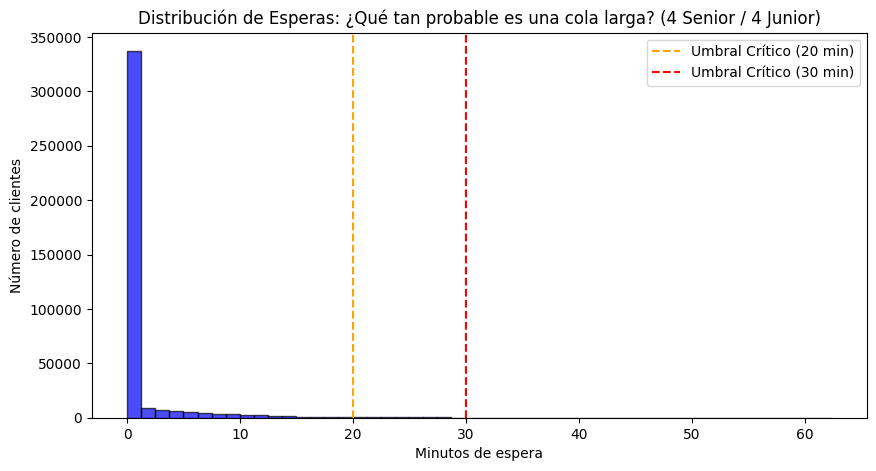

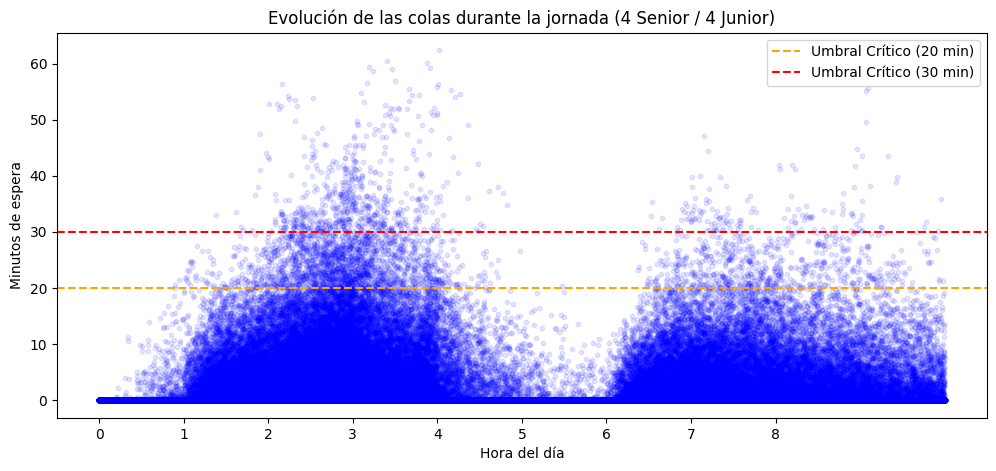

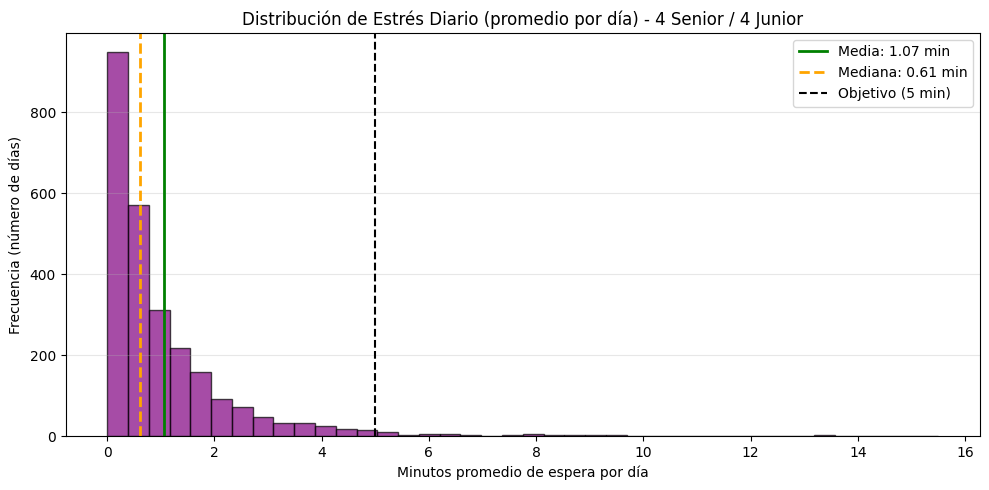

--- ANÁLISIS DE RIESGO (Individual) ---
- Probabilidad de que un cliente espere más de 20 min: 0.87%
- Probabilidad de que un cliente espere más de 30 min: 0.20%

--- ANÁLISIS DE ESTRÉS DIARIO ---
Media de estrés diario: 1.07 min
Mediana de estrés diario: 0.61 min
Desviación estándar: 1.41 min
Mínimo (mejor día): 0.00 min
Máximo (peor día): 15.50 min
Días con estrés > 5 min: 58 de 2600

--- ANÁLISIS GLOBAL ---
Total de personas atendidas: 389947
Total de personas que esperaron menos de 5 min: 359415
Total de personas que esperaron menos de 10 min: 375311


In [95]:
# Umbrales críticos
umbral_critico1 = 20  
umbral_critico2 = 30  
equipo_analizar = config_asesores_8_mixtos_1
n_jornadas = N_JORNADAS

total_personas_espera_larga = 0
total_personas_atendidas = 0
total_personas_espera_corta5 = 0
total_personas_espera_corta10 = 0

resultados_por_dia = []
todas_las_esperas = []
esperas_por_hora = []

# Simulación de cada jornada (UN SOLO BUCLE)
for _ in range(n_jornadas): 
    llegadas = generacion_llegadas(15, pesos_dia) 
    esperas = simulacion_atencion(equipo_analizar, llegadas)
    
    # Guardamos datos por cliente
    for t_llegada, espera in zip(llegadas, esperas):
        espera_min = espera * 60
        todas_las_esperas.append(espera_min)
        esperas_por_hora.append({'Hora': t_llegada, 'Espera': espera_min})
    
    # Estadísticas del día
    if esperas:
        esperas_minutos = [e * 60 for e in esperas]
        promedio_dia = sum(esperas_minutos) / len(esperas_minutos)
        resultados_por_dia.append(promedio_dia)
        gente_hoy_espera_menos_5 = sum(1 for m in esperas_minutos if m < 5)
        gente_hoy_espera_menos_10 = sum(1 for m in esperas_minutos if m < 10)
        total_personas_espera_corta5 += gente_hoy_espera_menos_5
        total_personas_espera_corta10 += gente_hoy_espera_menos_10
        total_personas_atendidas += len(llegadas)
    else:
        resultados_por_dia.append(0)

# resumen de listas largas sin imprimir todo
arr = np.array(todas_las_esperas)
print(f"esperas: n={len(arr)}, media={arr.mean():.2f}, p50={np.percentile(arr,50):.2f}, p90={np.percentile(arr,90):.2f}, p95={np.percentile(arr,95):.2f}")

df_detallado = pd.DataFrame(esperas_por_hora)

# --- 1. ¿CADA CUÁNTO HAY COLAS LARGAS? (Histograma de Riesgo) ---
plt.figure(figsize=(10, 5))
plt.hist(todas_las_esperas, bins=50, color='blue', edgecolor='black', alpha=0.7)
plt.axvline(umbral_critico1, color='orange', linestyle='--', label=f'Umbral Crítico ({umbral_critico1} min)')
plt.axvline(umbral_critico2, color='red', linestyle='--', label=f'Umbral Crítico ({umbral_critico2} min)')
plt.title("Distribución de Esperas: ¿Qué tan probable es una cola larga? (4 Senior / 4 Junior)")
plt.xlabel("Minutos de espera")
plt.ylabel("Número de clientes")
plt.legend()
plt.savefig('figures/hist_riesgo_4s_4j.png', dpi=200, bbox_inches='tight')
plt.show()

# Gráfica de espera en cola por cliente 
plt.figure(figsize=(12, 5))
plt.scatter(df_detallado['Hora'], df_detallado['Espera'], alpha=0.1, color='blue', s=10)
plt.title("Evolución de las colas durante la jornada (4 Senior / 4 Junior)")
plt.xlabel("Hora del día")
plt.ylabel("Minutos de espera")
plt.axhline(umbral_critico1, color='orange', linestyle='--', label=f'Umbral Crítico ({umbral_critico1} min)')
plt.axhline(umbral_critico2, color='red', linestyle='--', label=f'Umbral Crítico ({umbral_critico2} min)')
plt.xticks(range(9))
plt.legend()
plt.savefig('figures/cola_evolucion_4s_4j.png', dpi=200, bbox_inches='tight')
plt.show()

# --- HISTOGRAMA DE ESTRÉS DIARIO (Distribución de promedios diarios) ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(resultados_por_dia, bins=40, color='purple', edgecolor='black', alpha=0.7)
ax.axvline(np.mean(resultados_por_dia), color='green', linestyle='-', linewidth=2, label=f'Media: {np.mean(resultados_por_dia):.2f} min')
ax.axvline(np.median(resultados_por_dia), color='orange', linestyle='--', linewidth=2, label=f'Mediana: {np.median(resultados_por_dia):.2f} min')
ax.axvline(5, color='black', linestyle='--', label='Objetivo (5 min)')
ax.set_title("Distribución de Estrés Diario (promedio por día) - 4 Senior / 4 Junior")
ax.set_xlabel("Minutos promedio de espera por día")
ax.set_ylabel("Frecuencia (número de días)")
ax.legend()
ax.grid(axis='y', alpha=0.3)
fig.savefig('figures/estres_diario_4s_4j.png', dpi=200, bbox_inches='tight')
plt.tight_layout()
plt.show()

# --- MÉTRICAS DE CALIDAD DE SERVICIO (SLA) ---
prob_larga20 = (np.array(todas_las_esperas) > umbral_critico1).mean() * 100
prob_larga30 = (np.array(todas_las_esperas) > umbral_critico2).mean() * 100

print(f"--- ANÁLISIS DE RIESGO (Individual) ---")
print(f"- Probabilidad de que un cliente espere más de {umbral_critico1} min: {prob_larga20:.2f}%")
print(f"- Probabilidad de que un cliente espere más de {umbral_critico2} min: {prob_larga30:.2f}%")

print(f"\n--- ANÁLISIS DE ESTRÉS DIARIO ---")
print(f"Media de estrés diario: {np.mean(resultados_por_dia):.2f} min")
print(f"Mediana de estrés diario: {np.median(resultados_por_dia):.2f} min")
print(f"Desviación estándar: {np.std(resultados_por_dia):.2f} min")
print(f"Mínimo (mejor día): {np.min(resultados_por_dia):.2f} min")
print(f"Máximo (peor día): {np.max(resultados_por_dia):.2f} min")
print(f"Días con estrés > 5 min: {sum(1 for x in resultados_por_dia if x > 5)} de {n_jornadas}")

print(f"\n--- ANÁLISIS GLOBAL ---")
print(f"Total de personas atendidas: {total_personas_atendidas}")
print(f"Total de personas que esperaron menos de 5 min: {total_personas_espera_corta5}")
print(f"Total de personas que esperaron menos de 10 min: {total_personas_espera_corta10}")

if total_personas_atendidas > 0:
    satisfaccion = (total_personas_espera_corta10 / total_personas_atendidas) * 100


esperas: n=390487, media=1.66, p50=0.00, p90=5.78, p95=11.37


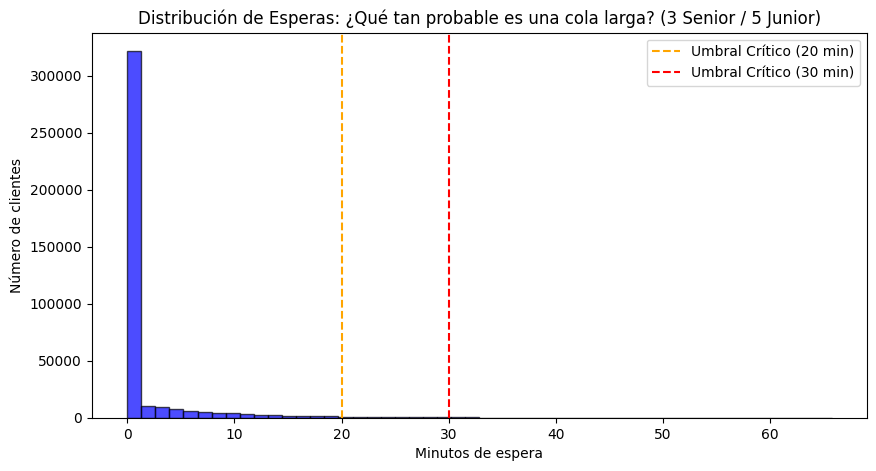

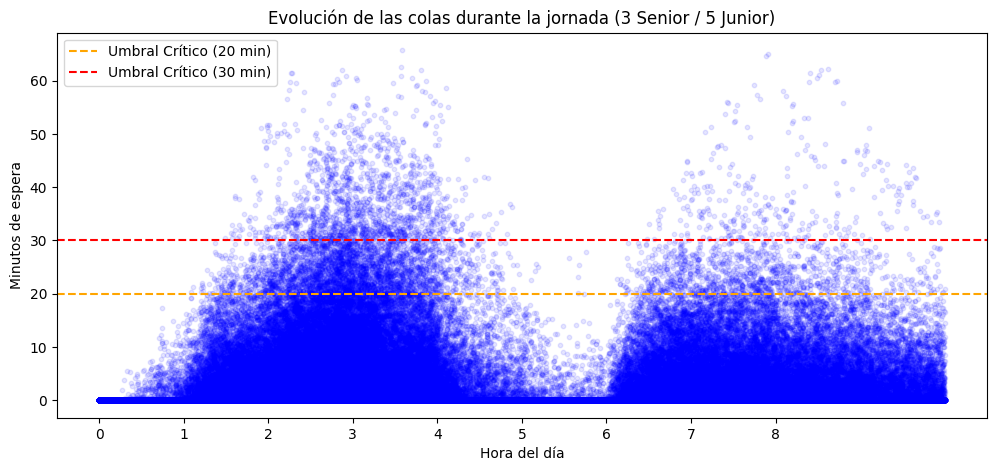

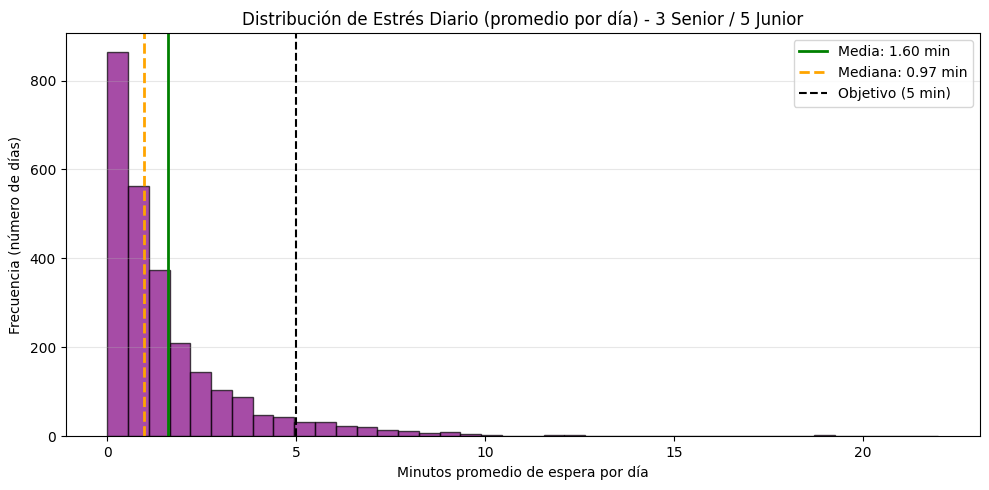

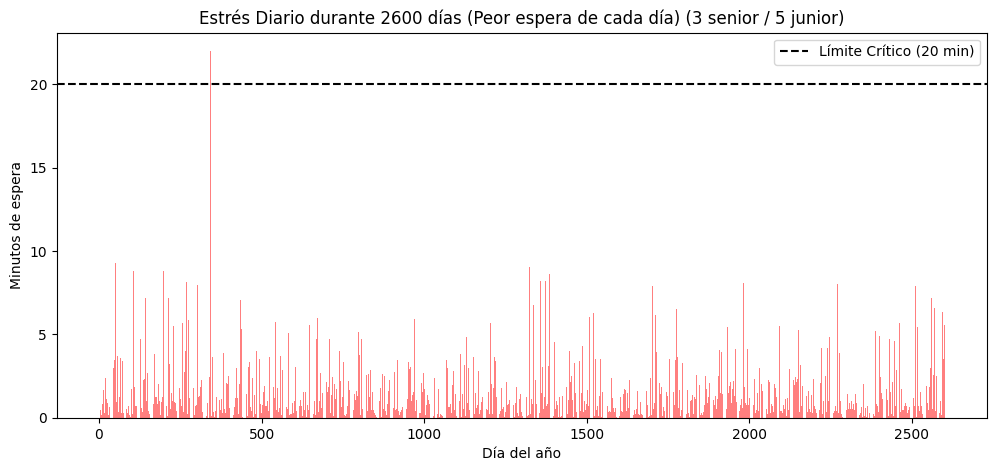

--- ANÁLISIS DE RIESGO (Individual) ---
- Probabilidad de que un cliente espere más de 20 min: 1.72%
- Probabilidad de que un cliente espere más de 30 min: 0.49%

--- ANÁLISIS DE ESTRÉS DIARIO ---
Media de estrés diario: 1.60 min
Mediana de estrés diario: 0.97 min
Desviación estándar: 1.93 min
Mínimo (mejor día): 0.00 min
Máximo (peor día): 22.00 min
Días con estrés > 5 min: 160 de 2600
Días con al menos un 'colapso' (>20 min): 1 de 2600

--- ANÁLISIS GLOBAL ---
Total de personas atendidas: 390487
Total de personas que esperaron menos de 5 min: 347411
Total de personas que esperaron menos de 10 min: 367341
Total de personas que esperaron mas de 20 min: 6724
Porcentaje de satisfacción (espera < 10 min): 94.07%
Porcentaje de insatisfacción: 1.72%


In [96]:
# Umbrales críticos
umbral_critico1 = 20  
umbral_critico2 = 30  
equipo_analizar = config_asesores_8_mixtos_2
n_jornadas = N_JORNADAS

total_personas_espera_larga = 0
total_personas_atendidas = 0
total_personas_espera_corta5 = 0
total_personas_espera_corta10 = 0

resultados_por_dia = []
todas_las_esperas = []
esperas_por_hora = []

# Simulación de cada jornada (UN SOLO BUCLE)
for _ in range(n_jornadas): 
    llegadas = generacion_llegadas(15, pesos_dia) 
    esperas = simulacion_atencion(equipo_analizar, llegadas)
    
    # Guardamos datos por cliente
    for t_llegada, espera in zip(llegadas, esperas):
        espera_min = espera * 60
        todas_las_esperas.append(espera_min)
        esperas_por_hora.append({'Hora': t_llegada, 'Espera': espera_min})
    
    # Estadísticas del día
    if esperas:
        esperas_minutos = [e * 60 for e in esperas]
        promedio_dia = sum(esperas_minutos) / len(esperas_minutos)
        resultados_por_dia.append(promedio_dia)
        gente_hoy_espera_menos_5 = sum(1 for m in esperas_minutos if m < 5)
        gente_hoy_espera_menos_10 = sum(1 for m in esperas_minutos if m < 10)
        gente_hoy_espera_mas_20 = sum(1 for m in esperas_minutos if m > 20)
        total_personas_espera_corta5 += gente_hoy_espera_menos_5
        total_personas_espera_corta10 += gente_hoy_espera_menos_10
        total_personas_espera_larga += gente_hoy_espera_mas_20
        total_personas_atendidas += len(llegadas)
    else:
        resultados_por_dia.append(0)

# Resumen estadístico de esperas
arr = np.array(todas_las_esperas)
print(f"esperas: n={len(arr)}, media={arr.mean():.2f}, p50={np.percentile(arr,50):.2f}, p90={np.percentile(arr,90):.2f}, p95={np.percentile(arr,95):.2f}")


df_detallado = pd.DataFrame(esperas_por_hora)

# --- 1. ¿CADA CUÁNTO HAY COLAS LARGAS? (Histograma de Riesgo) ---
plt.figure(figsize=(10, 5))
plt.hist(todas_las_esperas, bins=50, color='blue', edgecolor='black', alpha=0.7)
plt.axvline(umbral_critico1, color='orange', linestyle='--', label=f'Umbral Crítico ({umbral_critico1} min)')
plt.axvline(umbral_critico2, color='red', linestyle='--', label=f'Umbral Crítico ({umbral_critico2} min)')
plt.title("Distribución de Esperas: ¿Qué tan probable es una cola larga? (3 Senior / 5 Junior)")
plt.xlabel("Minutos de espera")
plt.ylabel("Número de clientes")
plt.legend()
plt.savefig('figures/hist_riesgo_3s_5j.png', dpi=200, bbox_inches='tight')
plt.show()

# Gráfica de espera en cola por cliente 
plt.figure(figsize=(12, 5))
plt.scatter(df_detallado['Hora'], df_detallado['Espera'], alpha=0.1, color='blue',s=10)
plt.title("Evolución de las colas durante la jornada (3 Senior / 5 Junior)")
plt.xlabel("Hora del día")
plt.ylabel("Minutos de espera")
plt.axhline(umbral_critico1, color='orange', linestyle='--', label=f'Umbral Crítico ({umbral_critico1} min)')
plt.axhline(umbral_critico2, color='red', linestyle='--', label=f'Umbral Crítico ({umbral_critico2} min)')
plt.xticks(range(9))
plt.legend()
plt.savefig('figures/cola_evolucion_3s_5j.png', dpi=200, bbox_inches='tight')
plt.show()

# --- HISTOGRAMA DE ESTRÉS DIARIO (Distribución de promedios diarios) ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(resultados_por_dia, bins=40, color='purple', edgecolor='black', alpha=0.7)
ax.axvline(np.mean(resultados_por_dia), color='green', linestyle='-', linewidth=2, label=f'Media: {np.mean(resultados_por_dia):.2f} min')
ax.axvline(np.median(resultados_por_dia), color='orange', linestyle='--', linewidth=2, label=f'Mediana: {np.median(resultados_por_dia):.2f} min')
ax.axvline(5, color='black', linestyle='--', label='Objetivo (5 min)')
ax.set_title("Distribución de Estrés Diario (promedio por día) - 3 Senior / 5 Junior")
ax.set_xlabel("Minutos promedio de espera por día")
ax.set_ylabel("Frecuencia (número de días)")
ax.legend()
ax.grid(axis='y', alpha=0.3)
fig.savefig('figures/estres_diario_3s_5j.png', dpi=200, bbox_inches='tight')
plt.tight_layout()
plt.show()

# 2. Gráfica de la "Peor Espera Diaria" (Riesgo)
plt.figure(figsize=(12, 5))
plt.bar(range(1, n_jornadas + 1), resultados_por_dia, color='red', alpha=0.5)
plt.axhline(umbral_critico1, color='black', linestyle='--', label='Límite Crítico (20 min)')
plt.title(f"Estrés Diario durante {n_jornadas} días (Peor espera de cada día) (3 senior / 5 junior)")
plt.xlabel("Día del año")
plt.ylabel("Minutos de espera")
plt.legend()
plt.savefig('figures/peor_espera_3s_5j.png', dpi=200, bbox_inches='tight')
plt.show()

# --- MÉTRICAS DE CALIDAD DE SERVICIO (SLA) ---
prob_larga20 = (np.array(todas_las_esperas) > umbral_critico1).mean() * 100
prob_larga30 = (np.array(todas_las_esperas) > umbral_critico2).mean() * 100

print(f"--- ANÁLISIS DE RIESGO (Individual) ---")
print(f"- Probabilidad de que un cliente espere más de {umbral_critico1} min: {prob_larga20:.2f}%")
print(f"- Probabilidad de que un cliente espere más de {umbral_critico2} min: {prob_larga30:.2f}%")

print(f"\n--- ANÁLISIS DE ESTRÉS DIARIO ---")
print(f"Media de estrés diario: {np.mean(resultados_por_dia):.2f} min")
print(f"Mediana de estrés diario: {np.median(resultados_por_dia):.2f} min")
print(f"Desviación estándar: {np.std(resultados_por_dia):.2f} min")
print(f"Mínimo (mejor día): {np.min(resultados_por_dia):.2f} min")
print(f"Máximo (peor día): {np.max(resultados_por_dia):.2f} min")
print(f"Días con estrés > 5 min: {sum(1 for x in resultados_por_dia if x > 5)} de {n_jornadas}")

print(f"Días con al menos un 'colapso' (>20 min): {sum(1 for x in resultados_por_dia if x > 20)} de {n_jornadas}")

print(f"\n--- ANÁLISIS GLOBAL ---")
print(f"Total de personas atendidas: {total_personas_atendidas}")
print(f"Total de personas que esperaron menos de 5 min: {total_personas_espera_corta5}")
print(f"Total de personas que esperaron menos de 10 min: {total_personas_espera_corta10}")
print(f"Total de personas que esperaron mas de 20 min: {total_personas_espera_larga}")

if total_personas_atendidas > 0:
    satisfaccion = (total_personas_espera_corta10 / total_personas_atendidas) * 100
    print(f"Porcentaje de satisfacción (espera < 10 min): {satisfaccion:.2f}%")
print(f"Porcentaje de insatisfacción: {(total_personas_espera_larga / total_personas_atendidas) * 100:.2f}%")

## Comparación de cortas esperas 

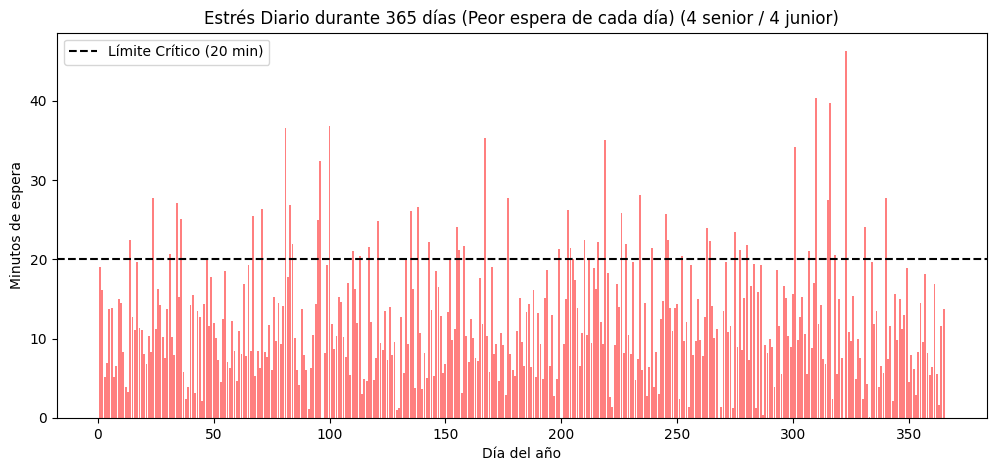

--- ANÁLISIS ANUAL ---
Total de personas atendidas al año: 54622
Total de personas que esperaron MÁS de 20 min: 394
Porcentaje de insatisfacción: 0.72%
Días con al menos un 'colapso' (>20 min): 57 de 365


In [97]:
# 1. Configuración
n_dias = N_DIAS  # Un año completo
equipo_a_probar = config_asesores_8_mixtos_1
resultados_por_dia = []
total_personas_espera_larga = 0
total_personas_atendidas = 0

for i in range(n_dias):
    # Generamos un día de trabajo
    llegadas = generacion_llegadas(15, pesos_dia)
    esperas = simulacion_atencion(equipo_a_probar, llegadas)
    
    if esperas:
        # Convertimos todas las esperas del día a minutos
        esperas_minutos = [e * 60 for e in esperas]
        
        # A. Guardamos la peor espera del día para la gráfica
        resultados_por_dia.append(max(esperas_minutos))
        
        # B. CONTAMOS PERSONAS: ¿Cuántos clientes hoy esperaron más de 20 min?
        gente_hoy_espera_mas_20 = sum(1 for m in esperas_minutos if m > 20)
        
        # C. Acumulamos totales
        total_personas_espera_larga += gente_hoy_espera_mas_20
        total_personas_atendidas += len(llegadas)
    else:
        resultados_por_dia.append(0)

# 2. Gráfica de la "Peor Espera Diaria" (Riesgo)
plt.figure(figsize=(12, 5))
plt.bar(range(1, n_dias + 1), resultados_por_dia, color='red', alpha=0.5)
plt.axhline(y=20, color='black', linestyle='--', label='Límite Crítico (20 min)')
plt.title(f"Estrés Diario durante {n_dias} días (Peor espera de cada día) (4 senior / 4 junior)")
plt.xlabel("Día del año")
plt.ylabel("Minutos de espera")
plt.legend()
plt.savefig('figures/peor_espera_4s_4j.png', dpi=200, bbox_inches='tight')
plt.show()

# 3. Resultados exactos
print(f"--- ANÁLISIS ANUAL ---")
print(f"Total de personas atendidas al año: {total_personas_atendidas}")
print(f"Total de personas que esperaron MÁS de 20 min: {total_personas_espera_larga}")
print(f"Porcentaje de insatisfacción: {(total_personas_espera_larga / total_personas_atendidas) * 100:.2f}%")
print(f"Días con al menos un 'colapso' (>20 min): {sum(1 for x in resultados_por_dia if x > 20)} de {n_dias}")

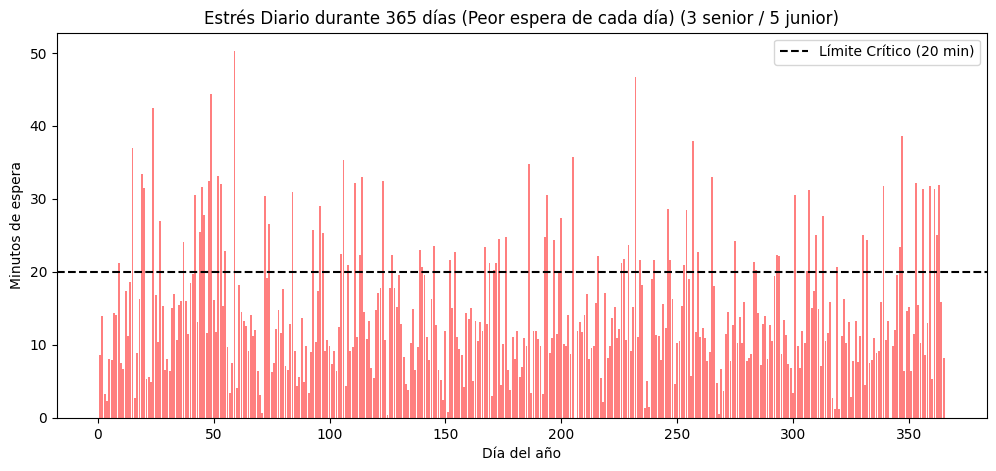

--- ANÁLISIS ANUAL ---
Total de personas atendidas al año: 54562
Total de personas que esperaron MÁS de 20 min: 800
Porcentaje de insatisfacción: 1.47%
Días con al menos un 'colapso' (>20 min): 85 de 365


In [98]:
# 1. Configuración
n_dias = N_DIAS  # Un año completo
equipo_a_probar = config_asesores_8_mixtos_2
resultados_por_dia = []
total_personas_espera_larga = 0
total_personas_atendidas = 0

for i in range(n_dias):
    # Generamos un día de trabajo
    llegadas = generacion_llegadas(15, pesos_dia)
    esperas = simulacion_atencion(equipo_a_probar, llegadas)
    
    if esperas:
        # Convertimos todas las esperas del día a minutos
        esperas_minutos = [e * 60 for e in esperas]
        
        # A. Guardamos la peor espera del día para la gráfica
        resultados_por_dia.append(max(esperas_minutos))
        
        # B. CONTAMOS PERSONAS: ¿Cuántos clientes hoy esperaron más de 20 min?
        gente_hoy_espera_mas_20 = sum(1 for m in esperas_minutos if m > 20)
        
        # C. Acumulamos totales
        total_personas_espera_larga += gente_hoy_espera_mas_20
        total_personas_atendidas += len(llegadas)
    else:
        resultados_por_dia.append(0)

# 2. Gráfica de la "Peor Espera Diaria" (Riesgo)
plt.figure(figsize=(12, 5))
plt.bar(range(1, n_dias + 1), resultados_por_dia, color='red', alpha=0.5)
plt.axhline(y=20, color='black', linestyle='--', label='Límite Crítico (20 min)')
plt.title(f"Estrés Diario durante {n_dias} días (Peor espera de cada día) (3 senior / 5 junior)")
plt.xlabel("Día del año")
plt.ylabel("Minutos de espera")
plt.legend()
plt.savefig('figures/peor_espera_3s_5j.png', dpi=200, bbox_inches='tight')
plt.show()

# 3. Resultados exactos
print(f"--- ANÁLISIS ANUAL ---")
print(f"Total de personas atendidas al año: {total_personas_atendidas}")
print(f"Total de personas que esperaron MÁS de 20 min: {total_personas_espera_larga}")
print(f"Porcentaje de insatisfacción: {(total_personas_espera_larga / total_personas_atendidas) * 100:.2f}%")
print(f"Días con al menos un 'colapso' (>20 min): {sum(1 for x in resultados_por_dia if x > 20)} de {n_dias}")

De esta manera queda muy claro el hecho de que el equipo de 4 senior y 4 junior es el mas rentable y además es el que garatiza que cada año menos días se supere el limite critico maximo y que menos personas esperen mas de 20 minutos cualquier día